# Binary coherent-state discrimination

This notebook establishes the basic theoretical benchmarks for the Dolinar receiver project.

We consider discrimination between two equally likely coherent states

$$
|\alpha\rangle
\qquad \text{and} \qquad
|-\alpha\rangle,
$$

where the mean photon number is

$$
\bar{n} = |\alpha|^2.
$$

We begin by comparing three receiver benchmarks:

- the Helstrom bound,
- homodyne detection,
- the Kennedy receiver.

I will later compare these with adaptive Dolinar-type feedback strategies.

In [70]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erfc

## 1. Helstrom bound

For two equally likely pure states $|\psi_0\rangle$ and $|\psi_1\rangle$, the minimum possible discrimination error is given by the Helstrom bound:

$$
P_\mathrm{Hel}
=
\frac{1}{2}
\left(
1-\sqrt{1-|\langle\psi_0|\psi_1\rangle|^2}
\right).
$$

For the coherent states $|\alpha\rangle$ and $|-\alpha\rangle$,

$$
|\langle\alpha|-\alpha\rangle|^2
=
e^{-4|\alpha|^2}.
$$

Defining the mean photon number

$$
\bar n = |\alpha|^2,
$$

the Helstrom bound becomes

$$
P_\mathrm{Hel}(\bar n)
=
\frac12
\left(
1-\sqrt{1-e^{-4\bar n}}
\right).
$$

This is the fundamental lower bound for the error probability in the ideal binary coherent-state discrimination problem.

In [71]:
def helstrom_error(nbar):
    "Helstrom error probability for equally likely coherent states |alpha> and |-alpha>."
    return 0.5 * (1 - np.sqrt(1 - np.exp(-4 * nbar)))

In [72]:
print("nbar = 0:  ", helstrom_error(0.0))
print("nbar = 0.1:", helstrom_error(0.1))
print("nbar = 0.5:", helstrom_error(0.5))
print("nbar = 1.0:", helstrom_error(1.0))
print("nbar = 2.0:", helstrom_error(2.0))

nbar = 0:   0.5
nbar = 0.1: 0.21291118361891875
nbar = 0.5: 0.03506325248390313
nbar = 1.0: 0.004600070369588705
nbar = 2.0: 8.387269160403665e-05


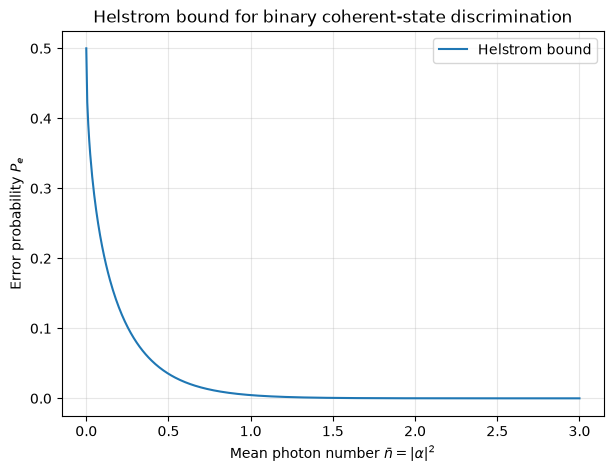

In [73]:
nbar = np.linspace(0, 3, 500)

p_helstrom = helstrom_error(nbar)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(nbar, p_helstrom, label="Helstrom bound")

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Helstrom bound for binary coherent-state discrimination")

ax.grid(alpha=0.3)
ax.legend()
fig.savefig(
    "../figures/helstrom_bound.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

## Kennedy receiver

The Kennedy receiver first displaces the incoming coherent state and then
performs on/off photon detection.

Choosing the displacement

$$
\beta = +\alpha
$$

gives

$$
|-\alpha\rangle \rightarrow |0\rangle,
$$

and

$$
|\alpha\rangle \rightarrow |2\alpha\rangle.
$$

The decision rule is

- no click $\rightarrow |-\alpha\rangle$,
- click $\rightarrow |\alpha\rangle$.

For a coherent state $|\gamma\rangle$, the probability of detecting no photons is

$$
P(0|\gamma)=e^{-|\gamma|^2}.
$$

An error only happens when the state was $|-\alpha\rangle$ AND you get no click.

So

$$P_{err} = P(-α) P(0|-α)$$
With equal prior probabilities, the Kennedy receiver therefore has error probability

$$
P_{\mathrm{K}}
=
\frac{1}{2}e^{-4\bar{n}}.
$$

In [74]:
def no_click_probability(amplitude):
    # Probability of no click for an ideal on/off detector.
    return np.exp(-np.abs(amplitude)**2)


def click_probability(amplitude):
    # Probability of one or more photons being detected.
    return 1 - no_click_probability(amplitude)

In [75]:
print("Vacuum:")
print("No click:", no_click_probability(0))
print("Click:   ", click_probability(0))

Vacuum:
No click: 1.0
Click:    0.0


In [76]:
def kennedy_error(nbar):
    # Error probability of the ideal Kennedy receiver
    alpha = np.sqrt(nbar)

    # Displace by +alpha.
    displaced_minus = -alpha + alpha   # -> 0
    displaced_plus = alpha + alpha     # -> 2 alpha

    # Decision:
    # no click -> guess -alpha
    # click    -> guess +alpha

    error_given_minus = click_probability(displaced_minus)
    error_given_plus = no_click_probability(displaced_plus)

    return 0.5 * error_given_minus + 0.5 * error_given_plus

In [77]:
print("nbar = 0:  ", kennedy_error(0.0))
print("nbar = 0.1:", kennedy_error(0.1))
print("nbar = 0.5:", kennedy_error(0.5))
print("nbar = 1.0:", kennedy_error(1.0))
print("nbar = 2.0:", kennedy_error(2.0))

nbar = 0:   0.5
nbar = 0.1: 0.33516002301781966
nbar = 0.5: 0.06766764161830631
nbar = 1.0: 0.00915781944436709
nbar = 2.0: 0.00016773131395125563


In [78]:
def kennedy_error_analytic(nbar):
    return 0.5 * np.exp(-4 * nbar)


assert np.allclose(
    kennedy_error(nbar),
    kennedy_error_analytic(nbar)
)

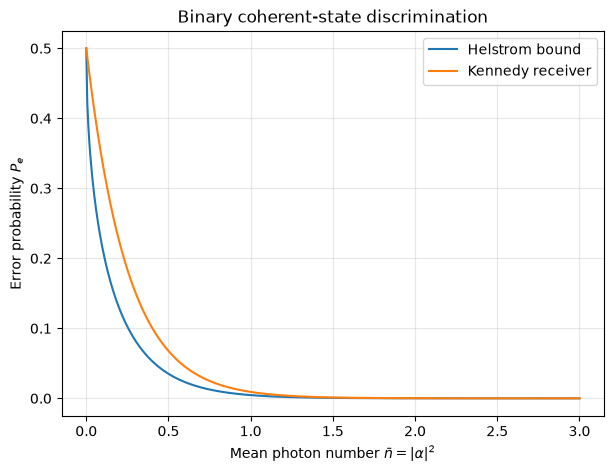

In [79]:
p_helstrom = helstrom_error(nbar)
p_kennedy = kennedy_error(nbar)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(nbar, p_helstrom, label="Helstrom bound")
ax.plot(nbar, p_kennedy, label="Kennedy receiver")

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Binary coherent-state discrimination")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## Homodyne detection

For real $\alpha$, measuring
the $X$ quadrature gives two Gaussian probability distributions centered at

$$
\langle X\rangle_{\pm\alpha}
=
\pm\sqrt{2}\alpha.
$$

For equally likely states, the optimal decision boundary is $x=0$:

- $x>0 \rightarrow |\alpha\rangle$,
- $x<0 \rightarrow |-\alpha\rangle$.

The error probability is the Gaussian probability lying on the wrong side
of the decision boundary,

$$
P_{\mathrm{hom}}
=
\frac{1}{2}
\operatorname{erfc}\left(\sqrt{2\bar{n}}\right).
$$

In [80]:
from scipy.special import erfc

In [81]:
def homodyne_error(nbar):
    # Error probability for ideal homodyne discrimination of |±alpha>
    return 0.5 * erfc(np.sqrt(2 * nbar))

In [82]:
print("nbar = 0:  ", homodyne_error(0.0))
print("nbar = 0.1:", homodyne_error(0.1))
print("nbar = 0.5:", homodyne_error(0.5))
print("nbar = 1.0:", homodyne_error(1.0))

nbar = 0:   0.5
nbar = 0.1: 0.26354462843276905
nbar = 0.5: 0.07864960352514258
nbar = 1.0: 0.022750131948179195


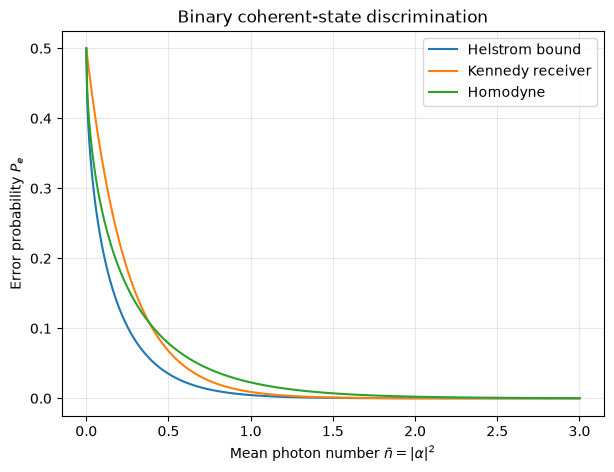

In [83]:
p_helstrom = helstrom_error(nbar)
p_kennedy = kennedy_error(nbar)
p_homodyne = homodyne_error(nbar)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(nbar, p_helstrom, label="Helstrom bound")
ax.plot(nbar, p_kennedy, label="Kennedy receiver")
ax.plot(nbar, p_homodyne, label="Homodyne")

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Binary coherent-state discrimination")

ax.grid(alpha=0.3)
ax.legend()

fig.savefig(
    "../figures/receiver_benchmarks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## QuTip Simulation

To include some direct quantum simulation, a QuTip simulation of the Kennedy receiver will also be made.

This will simulate a shot based experiment, where two equal prior coherent states are prepared, displaced, and then detected in a photon detector.

In [84]:
import qutip as qt

In [85]:
def kennedy_shots(nbar, shots=10_000, cutoff=30, seed=None):
    
    #Simulate repeated Kennedy-receiver measurements using QuTiP.
    #Returns the empirical discrimination error probability.

    rng = np.random.default_rng(seed)

    alpha = np.sqrt(nbar)

    # Coherent input states
    psi_plus = qt.coherent(cutoff, alpha)
    psi_minus = qt.coherent(cutoff, -alpha)

    # Kennedy displacement: beta = +alpha
    D = qt.displace(cutoff, alpha)

    displaced_plus = D * psi_plus
    displaced_minus = D * psi_minus

    # Photon-number probabilities after displacement
    p_plus = np.abs(displaced_plus.full().ravel()) ** 2
    p_minus = np.abs(displaced_minus.full().ravel()) ** 2

    photon_numbers = np.arange(cutoff)

    errors = 0

    for _ in range(shots):
        # Sender randomly chooses +alpha or -alpha
        sent_plus = rng.random() < 0.5

        if sent_plus:
            n = rng.choice(photon_numbers, p=p_plus / p_plus.sum())
        else:
            n = rng.choice(photon_numbers, p=p_minus / p_minus.sum())

        # Kennedy decision rule
        clicked = n > 0
        guessed_plus = clicked

        if guessed_plus != sent_plus:
            errors += 1

    return errors / shots

In [86]:
nbar_values = np.linspace(0, 2, 25)

simulated_errors = []

for i, n in enumerate(nbar_values):
    error = kennedy_shots(
        n,
        shots=5_000,
        cutoff=30,
        seed=1234 + i
    )
    simulated_errors.append(error)

In [87]:
nbar_theory = np.linspace(0, 2, 500)
kennedy_theory = 0.5 * np.exp(-4 * nbar_theory)

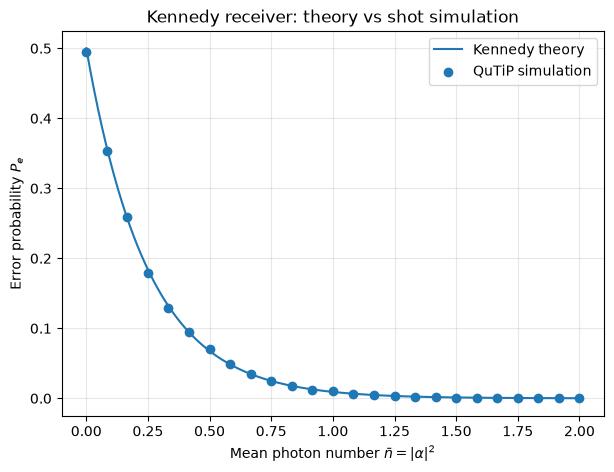

In [88]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    nbar_theory,
    kennedy_theory,
    label="Kennedy theory"
)

ax.scatter(
    nbar_values,
    simulated_errors,
    label="QuTiP simulation",
    zorder=3
)

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Kennedy receiver: theory vs shot simulation")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## General fixed displacement receiver

The Kennedy receiver is a special case of a more general displacement receiver.

Before photon detection, an arbitrary displacement $\beta$ is applied,

$$
|\alpha\rangle \rightarrow |\alpha+\beta\rangle,
$$

$$
|-\alpha\rangle \rightarrow |-\alpha+\beta\rangle.
$$

For an ideal on/off detector, the no-click and click probabilities are

$$
P(0|\gamma)=e^{-|\gamma|^2},
$$

and

$$
P(1|\gamma)=1-e^{-|\gamma|^2}.
$$

For each detector outcome, the receiver chooses whichever input hypothesis
is more likely. This allows the error probability to be calculated for any
fixed displacement $\beta$.

For example, we calculate

$$
P(0|+\alpha)
\qquad \text{and} \qquad
P(0|-\alpha).
$$

If the detector gives a no-click outcome, we ask:

  Which of $+\alpha$ or $-\alpha$ was more likely to have produced this outcome?

We then guess the more likely state. The error contribution is therefore the probability associated with the less likely hypothesis.

In [89]:
def fixed_displacement_error(nbar, beta):
    #Error probability for an ideal fixed-displacement on/off receiver
    
    alpha = np.sqrt(nbar)

    # Coherent amplitudes after displacement
    amp_plus = alpha + beta
    amp_minus = -alpha + beta

    # Conditional detector probabilities
    p0_plus = no_click_probability(amp_plus)
    p0_minus = no_click_probability(amp_minus)

    p1_plus = 1 - p0_plus
    p1_minus = 1 - p0_minus

    # Equal priors.
    # For each outcome, choose whichever hypothesis is more likely.
    error_no_click = 0.5 * np.minimum(p0_plus, p0_minus)
    error_click = 0.5 * np.minimum(p1_plus, p1_minus)

    return error_no_click + error_click

In [90]:
nbar_test = 0.5
alpha_test = np.sqrt(nbar_test)

general_result = fixed_displacement_error(
    nbar_test,
    beta=alpha_test
)

kennedy_result = kennedy_error(nbar_test)

print("General receiver:", general_result)
print("Kennedy receiver:", kennedy_result)

General receiver: 0.06766764161830631
Kennedy receiver: 0.06766764161830631


In [91]:
nbar_test = 0.5
alpha_test = np.sqrt(nbar_test)

beta_values = np.linspace(-2, 2, 500)

errors = np.array([
    fixed_displacement_error(nbar_test, beta)
    for beta in beta_values
])

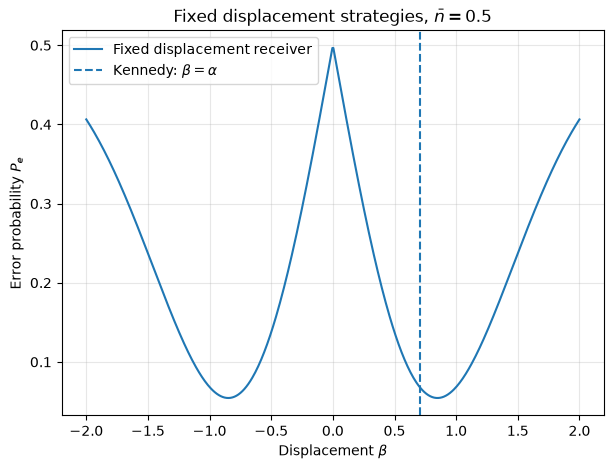

In [92]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(beta_values, errors, label="Fixed displacement receiver")

ax.axvline(
    alpha_test,
    linestyle="--",
    label=r"Kennedy: $\beta=\alpha$"
)

ax.set_xlabel(r"Displacement $\beta$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title(
    rf"Fixed displacement strategies, $\bar{{n}}={nbar_test}$"
)

ax.grid(alpha=0.3)
ax.legend()

plt.show()

### Why vary the displacement?

The Kennedy receiver chooses

$$
\beta = \alpha,
$$

which perfectly nulls one of the hypotheses,

$$
|-\alpha\rangle \rightarrow |0\rangle.
$$

However, perfectly nulling one state does not necessarily minimize the **total**
error probability. Choosing a slightly different displacement can introduce a
small probability of error for the previously nulled state while reducing the
error probability for the other state by a larger amount.

Therefore, the Kennedy receiver is only one possible fixed-displacement
strategy. By varying $\beta$, we can investigate whether another fixed
displacement gives a lower total discrimination error.

The next goal is therefore to determine the optimal fixed displacement

$$
\beta_{\mathrm{opt}}
=
\operatorname*{arg\,min}_{\beta} P_e(\beta).
$$

In [93]:
from scipy.optimize import minimize_scalar

In [94]:
def optimized_displacement(nbar):
    #Find the fixed displacement beta that minimizes the error probability

    if np.isclose(nbar, 0):
        return 0.0, 0.5

    alpha = np.sqrt(nbar)

    result = minimize_scalar(
        lambda beta: fixed_displacement_error(nbar, beta),
        bounds=(0, 2 * alpha + 2),
        method="bounded" #We can use only positive displacements, since the problem is symmetric
    )

    return result.x, result.fun

In [95]:
beta_opt, error_opt = optimized_displacement(0.5)

print("Optimal beta:", beta_opt)
print("Optimal error:", error_opt)
print("Kennedy beta:", np.sqrt(0.5))
print("Kennedy error:", kennedy_error(0.5))

Optimal beta: 0.8483003206938571
Optimal error: 0.054361438961019116
Kennedy beta: 0.7071067811865476
Kennedy error: 0.06766764161830631


In [96]:
#We optimize over many photon numbers to see how the optimal displacement changes with nbar.
nbar_values = np.linspace(0, 2, 150)

beta_opt_values = []
optimized_errors = []

for n in nbar_values:
    beta_opt, error_opt = optimized_displacement(n)

    beta_opt_values.append(beta_opt)
    optimized_errors.append(error_opt)

beta_opt_values = np.array(beta_opt_values)
optimized_errors = np.array(optimized_errors)

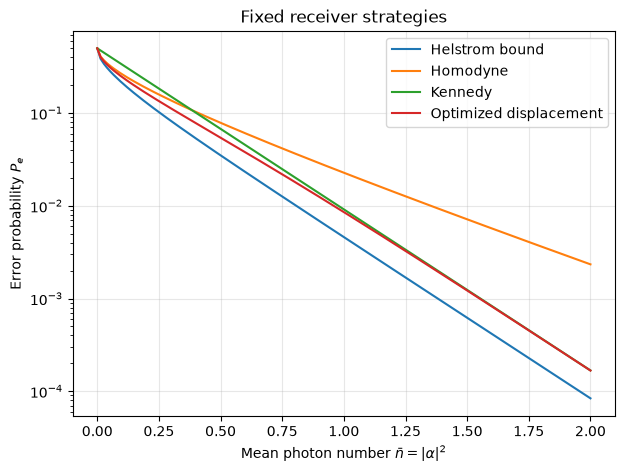

In [97]:
#Then make our fixed-receiver comparison.
p_helstrom = helstrom_error(nbar_values)
p_kennedy = kennedy_error(nbar_values)
p_homodyne = homodyne_error(nbar_values)

fig, ax = plt.subplots(figsize=(7, 5))

ax.semilogy(
    nbar_values,
    p_helstrom,
    label="Helstrom bound"
)

ax.semilogy(
    nbar_values,
    p_homodyne,
    label="Homodyne"
)

ax.semilogy(
    nbar_values,
    p_kennedy,
    label="Kennedy"
)

ax.semilogy(
    nbar_values,
    optimized_errors,
    label="Optimized displacement"
)

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Fixed receiver strategies")

ax.grid(alpha=0.3)
ax.legend()

fig.savefig(
    "../figures/fixed_receiver_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

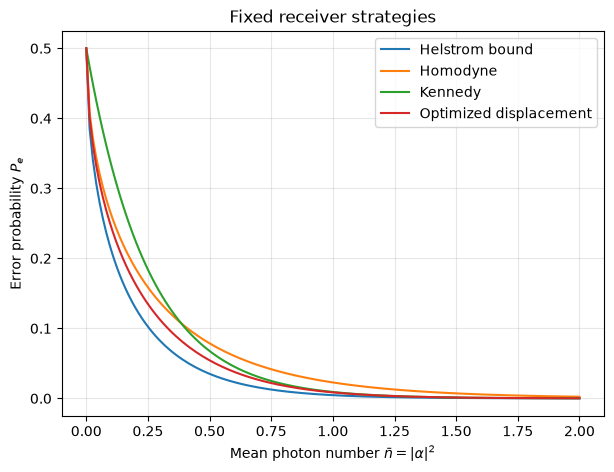

In [98]:
#Then make our fixed-receiver comparison non-logarithmic.
p_helstrom = helstrom_error(nbar_values)
p_kennedy = kennedy_error(nbar_values)
p_homodyne = homodyne_error(nbar_values)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    nbar_values,
    p_helstrom,
    label="Helstrom bound"
)

ax.plot(
    nbar_values,
    p_homodyne,
    label="Homodyne"
)

ax.plot(
    nbar_values,
    p_kennedy,
    label="Kennedy"
)

ax.plot(
    nbar_values,
    optimized_errors,
    label="Optimized displacement"
)

ax.set_xlabel(r"Mean photon number $\bar{n}=|\alpha|^2$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Fixed receiver strategies")

ax.grid(alpha=0.3)
ax.legend()

fig.savefig(
    "../figures/fixed_receiver_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

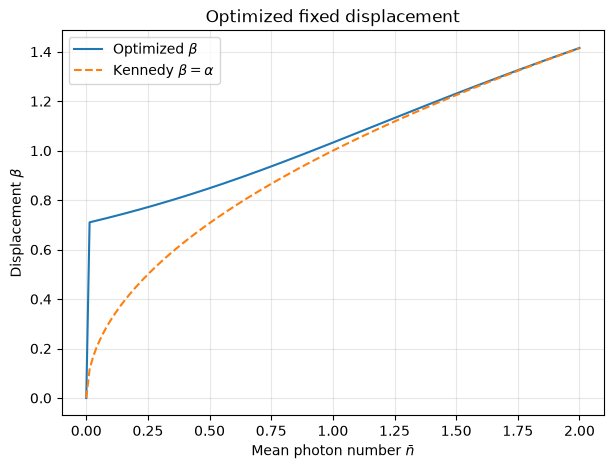

In [99]:
alpha_values = np.sqrt(nbar_values)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    nbar_values,
    beta_opt_values,
    label=r"Optimized $\beta$"
)

ax.plot(
    nbar_values,
    alpha_values,
    linestyle="--",
    label=r"Kennedy $\beta=\alpha$"
)

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(r"Displacement $\beta$")
ax.set_title("Optimized fixed displacement")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

for the adaptive receiver, that isn't necessarily the best β overall, because we care about the error after both bins. A slightly worse first measurement could give information that allows the second adaptive measurement to perform better.